# 05. Model Ensembling - BrechApp

**Objetivo:** Combinar las predicciones de múltiples modelos para mejorar la precisión.

**Contenido:**
1. Carga de predicciones de modelos individuales
2. Ensemble por promedio ponderado
3. Ensemble por stacking (meta-modelo)
4. Evaluación y comparación
5. Selección del mejor modelo
6. Guardado del modelo final

In [18]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import os
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✓ Librerías importadas')

✓ Librerías importadas


## 1. Carga de Datos y Predicciones

In [19]:
# Cargar predicciones del notebook anterior
with open('../src/models/models/ensemble_predictions.json', 'r') as f:
    ensemble_data = json.load(f)

# Extraer datos
dates_val = pd.to_datetime(ensemble_data['dates_val'])
y_true = np.array(ensemble_data['y_true_val'])

# Predicciones de modelos individuales
pred_arima = np.array(ensemble_data['predictions']['arima'])
pred_lgb = np.array(ensemble_data['predictions']['lightgbm'])

# Verificar si N-BEATS está disponible
has_nbeats = 'nbeats' in ensemble_data['predictions']
if has_nbeats:
    pred_nbeats = np.array(ensemble_data['predictions']['nbeats'])
    print('✓ N-BEATS disponible')
else:
    print('⚠ N-BEATS no disponible')

print(f'\nDatos cargados:')
print(f'  Fechas: {len(dates_val)}')
print(f'  Valores reales: {len(y_true)}')
print(f'  Predicciones ARIMA: {len(pred_arima)}')
print(f'  Predicciones LightGBM: {len(pred_lgb)}')
if has_nbeats:
    print(f'  Predicciones N-BEATS: {len(pred_nbeats)}')

⚠ N-BEATS no disponible

Datos cargados:
  Fechas: 587
  Valores reales: 587
  Predicciones ARIMA: 587
  Predicciones LightGBM: 587


In [20]:
# Cargar métricas individuales
metrics_summary = pd.read_csv('../src/models/models/metrics_summary.csv')
print('\nMétricas de modelos individuales:')
print(metrics_summary.to_string(index=False))


Métricas de modelos individuales:
   Model        MAE       RMSE  MAPE (%)
   ARIMA 366.795934 476.577101 46.423980
LightGBM 341.986693 455.706924 41.880009


## 2. Ensemble por Promedio Simple

In [21]:
# Promedio simple de todos los modelos
if has_nbeats:
    # Ajustar longitudes si N-BEATS tiene diferente tamaño
    min_len = min(len(pred_arima), len(pred_lgb), len(pred_nbeats))
    pred_simple = (pred_arima[:min_len] + pred_lgb[:min_len] + pred_nbeats[:min_len]) / 3
    y_true_adj = y_true[:min_len]
    dates_adj = dates_val[:min_len]
else:
    min_len = min(len(pred_arima), len(pred_lgb))
    pred_simple = (pred_arima[:min_len] + pred_lgb[:min_len]) / 2
    y_true_adj = y_true[:min_len]
    dates_adj = dates_val[:min_len]

# Métricas
mae_simple = mean_absolute_error(y_true_adj, pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_true_adj, pred_simple))
mape_simple = np.mean(np.abs((y_true_adj - pred_simple) / y_true_adj)) * 100
r2_simple = r2_score(y_true_adj, pred_simple)

print('\nEnsemble - Promedio Simple:')
print(f'  MAE: {mae_simple:.2f}')
print(f'  RMSE: {rmse_simple:.2f}')
print(f'  MAPE: {mape_simple:.2f}%')
print(f'  R²: {r2_simple:.4f}')


Ensemble - Promedio Simple:
  MAE: 354.27
  RMSE: 466.08
  MAPE: 44.11%
  R²: -1.3462


## 3. Ensemble por Promedio Ponderado

In [22]:
# Calcular pesos basados en el inverso del MAE
mae_arima = metrics_summary[metrics_summary['Model'] == 'ARIMA']['MAE'].values[0]
mae_lgb = metrics_summary[metrics_summary['Model'] == 'LightGBM']['MAE'].values[0]

if has_nbeats:
    mae_nbeats = metrics_summary[metrics_summary['Model'] == 'N-BEATS']['MAE'].values[0]
    
    # Pesos inversamente proporcionales al MAE
    w_arima = 1 / mae_arima
    w_lgb = 1 / mae_lgb
    w_nbeats = 1 / mae_nbeats
    
    # Normalizar pesos
    total_weight = w_arima + w_lgb + w_nbeats
    w_arima /= total_weight
    w_lgb /= total_weight
    w_nbeats /= total_weight
    
    pred_weighted = (w_arima * pred_arima[:min_len] + 
                     w_lgb * pred_lgb[:min_len] + 
                     w_nbeats * pred_nbeats[:min_len])
    
    print(f'Pesos calculados:')
    print(f'  ARIMA: {w_arima:.4f}')
    print(f'  LightGBM: {w_lgb:.4f}')
    print(f'  N-BEATS: {w_nbeats:.4f}')
else:
    w_arima = 1 / mae_arima
    w_lgb = 1 / mae_lgb
    
    total_weight = w_arima + w_lgb
    w_arima /= total_weight
    w_lgb /= total_weight
    
    pred_weighted = (w_arima * pred_arima[:min_len] + 
                     w_lgb * pred_lgb[:min_len])
    
    print(f'Pesos calculados:')
    print(f'  ARIMA: {w_arima:.4f}')
    print(f'  LightGBM: {w_lgb:.4f}')

# Métricas
mae_weighted = mean_absolute_error(y_true_adj, pred_weighted)
rmse_weighted = np.sqrt(mean_squared_error(y_true_adj, pred_weighted))
mape_weighted = np.mean(np.abs((y_true_adj - pred_weighted) / y_true_adj)) * 100
r2_weighted = r2_score(y_true_adj, pred_weighted)

print(f'\nEnsemble - Promedio Ponderado:')
print(f'  MAE: {mae_weighted:.2f}')
print(f'  RMSE: {rmse_weighted:.2f}')
print(f'  MAPE: {mape_weighted:.2f}%')
print(f'  R²: {r2_weighted:.4f}')

Pesos calculados:
  ARIMA: 0.4825
  LightGBM: 0.5175

Ensemble - Promedio Ponderado:
  MAE: 353.84
  RMSE: 465.71
  MAPE: 44.03%
  R²: -1.3425


## 4. Ensemble por Stacking (Meta-Modelo)

In [23]:
# Preparar datos para stacking
if has_nbeats:
    X_stack = np.column_stack([pred_arima[:min_len], 
                                pred_lgb[:min_len], 
                                pred_nbeats[:min_len]])
else:
    X_stack = np.column_stack([pred_arima[:min_len], 
                                pred_lgb[:min_len]])

# División para entrenamiento y validación del meta-modelo
split_idx = int(len(X_stack) * 0.7)
X_stack_train = X_stack[:split_idx]
y_stack_train = y_true_adj[:split_idx]
X_stack_val = X_stack[split_idx:]
y_stack_val = y_true_adj[split_idx:]

print(f'Datos para stacking:')
print(f'  Train: {X_stack_train.shape}')
print(f'  Val: {X_stack_val.shape}')

Datos para stacking:
  Train: (410, 2)
  Val: (177, 2)


In [24]:
# Seleccionar el mejor modelo basado en MAE
best_model_name = comparison_df.iloc[0]['Modelo']
best_mae = comparison_df.iloc[0]['MAE']

print(f'\n🏆 MEJOR MODELO: {best_model_name}')
print(f'   MAE: {best_mae:.2f}')
print(f'   RMSE: {comparison_df.iloc[0]["RMSE"]:.2f}')
print(f'   MAPE: {comparison_df.iloc[0]["MAPE"]:.2f}%')

# Determinar qué predicciones usar
if 'Simple' in best_model_name:
    best_predictions = pred_simple
elif 'Ponderado' in best_model_name:
    best_predictions = pred_weighted
elif 'Stacking' in best_model_name:
    # Es un meta-modelo
    meta_name = best_model_name.split('(')[1].split(')')[0]
    best_predictions = meta_results[meta_name]['predictions']
    best_model_obj = meta_results[meta_name]['model']
else:
    # Es un modelo individual (ARIMA o LightGBM o N-BEATS)
    if best_model_name == 'ARIMA':
        best_predictions = pred_arima[:min_len]
    elif best_model_name == 'LightGBM':
        best_predictions = pred_lgb[:min_len]
    elif has_nbeats and best_model_name == 'N-BEATS':
        best_predictions = pred_nbeats[:min_len]


🏆 MEJOR MODELO: LightGBM
   MAE: 341.99
   RMSE: 455.71
   MAPE: 41.88%


# Visualizar predicciones del mejor modelo
plt.figure(figsize=(15, 6))

if 'Stacking' in best_model_name:
    # Para stacking, usar solo la parte de validación
    plt.plot(dates_adj[split_idx:], y_stack_val, label='Real', linewidth=2, marker='o', markersize=3)
    plt.plot(dates_adj[split_idx:], best_predictions, label=f'{best_model_name}', 
             linewidth=2, linestyle='--', marker='s', markersize=3)
else:
    # Para ensembles y modelos individuales
    plt.plot(dates_adj, y_true_adj, label='Real', linewidth=2, marker='o', markersize=3)
    plt.plot(dates_adj, best_predictions, label=f'{best_model_name}', 
             linewidth=2, linestyle='--', marker='s', markersize=3)

plt.title(f'Mejor Modelo: {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio Blue (ARS)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../src/models/models/best_model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Gráfico guardado en ../src/models/models/best_model_predictions.png')

In [25]:
# Crear DataFrame con todas las métricas
comparison_data = {
    'Modelo': ['ARIMA', 'LightGBM'],
    'MAE': [mae_arima, mae_lgb],
    'RMSE': [metrics_summary[metrics_summary['Model'] == 'ARIMA']['RMSE'].values[0],
             metrics_summary[metrics_summary['Model'] == 'LightGBM']['RMSE'].values[0]],
    'MAPE': [metrics_summary[metrics_summary['Model'] == 'ARIMA']['MAPE (%)'].values[0],
             metrics_summary[metrics_summary['Model'] == 'LightGBM']['MAPE (%)'].values[0]]
}

if has_nbeats:
    comparison_data['Modelo'].append('N-BEATS')
    comparison_data['MAE'].append(mae_nbeats)
    comparison_data['RMSE'].append(metrics_summary[metrics_summary['Model'] == 'N-BEATS']['RMSE'].values[0])
    comparison_data['MAPE'].append(metrics_summary[metrics_summary['Model'] == 'N-BEATS']['MAPE (%)'].values[0])

# Agregar ensembles
comparison_data['Modelo'].extend(['Ensemble Simple', 'Ensemble Ponderado'])
comparison_data['MAE'].extend([mae_simple, mae_weighted])
comparison_data['RMSE'].extend([rmse_simple, rmse_weighted])
comparison_data['MAPE'].extend([mape_simple, mape_weighted])

# Agregar meta-modelos
for name, results in meta_results.items():
    comparison_data['Modelo'].append(f'Stacking ({name})')
    comparison_data['MAE'].append(results['mae'])
    comparison_data['RMSE'].append(results['rmse'])
    comparison_data['MAPE'].append(results['mape'])

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('MAE')

print('\n' + '='*70)
print('COMPARACIÓN COMPLETA DE MODELOS')
print('='*70)
print(comparison_df.to_string(index=False))
print('='*70)


COMPARACIÓN COMPLETA DE MODELOS
                 Modelo        MAE       RMSE      MAPE
               LightGBM 341.986693 455.706924 41.880009
     Ensemble Ponderado 353.835550 465.712327 44.029908
        Ensemble Simple 354.272877 466.077554 44.110515
                  ARIMA 366.795934 476.577101 46.423980
Stacking (RandomForest) 456.886261 506.388319 43.377415
       Stacking (Ridge) 516.145488 538.101030 49.556877
       Stacking (Lasso) 516.201402 538.069796 49.563401


In [26]:
# Guardar configuración del mejor modelo
final_model_config = {
    'best_model': best_model_name,
    'metrics': {
        'mae': float(comparison_df.iloc[0]['MAE']),
        'rmse': float(comparison_df.iloc[0]['RMSE']),
        'mape': float(comparison_df.iloc[0]['MAPE'])
    },
    'ensemble_type': None,
    'weights': None,
    'meta_model': None
}

# Guardar información específica según el tipo de modelo
if 'Simple' in best_model_name:
    final_model_config['ensemble_type'] = 'simple_average'
    if has_nbeats:
        final_model_config['weights'] = [1/3, 1/3, 1/3]
    else:
        final_model_config['weights'] = [0.5, 0.5]
        
elif 'Ponderado' in best_model_name:
    final_model_config['ensemble_type'] = 'weighted_average'
    if has_nbeats:
        final_model_config['weights'] = [float(w_arima), float(w_lgb), float(w_nbeats)]
    else:
        final_model_config['weights'] = [float(w_arima), float(w_lgb)]
        
elif 'Stacking' in best_model_name:
    final_model_config['ensemble_type'] = 'stacking'
    meta_name = best_model_name.split('(')[1].split(')')[0]
    final_model_config['meta_model'] = meta_name
    
    # Guardar el meta-modelo
    with open('../src/models/models/meta_model.pkl', 'wb') as f:
        pickle.dump(best_model_obj, f)
    print('✓ Meta-modelo guardado')
else:
    # Modelo individual
    final_model_config['ensemble_type'] = 'individual'

# Guardar configuración
with open('../src/models/models/final_model_config.json', 'w') as f:
    json.dump(final_model_config, f, indent=4)

print('\n✓ Configuración del modelo final guardada')
print(f'  Tipo: {final_model_config["ensemble_type"]}')
if final_model_config['weights']:
    print(f'  Pesos: {final_model_config["weights"]}')
if final_model_config['meta_model']:
    print(f'  Meta-modelo: {final_model_config["meta_model"]}')


✓ Configuración del modelo final guardada
  Tipo: individual


## 6. Selección del Mejor Modelo

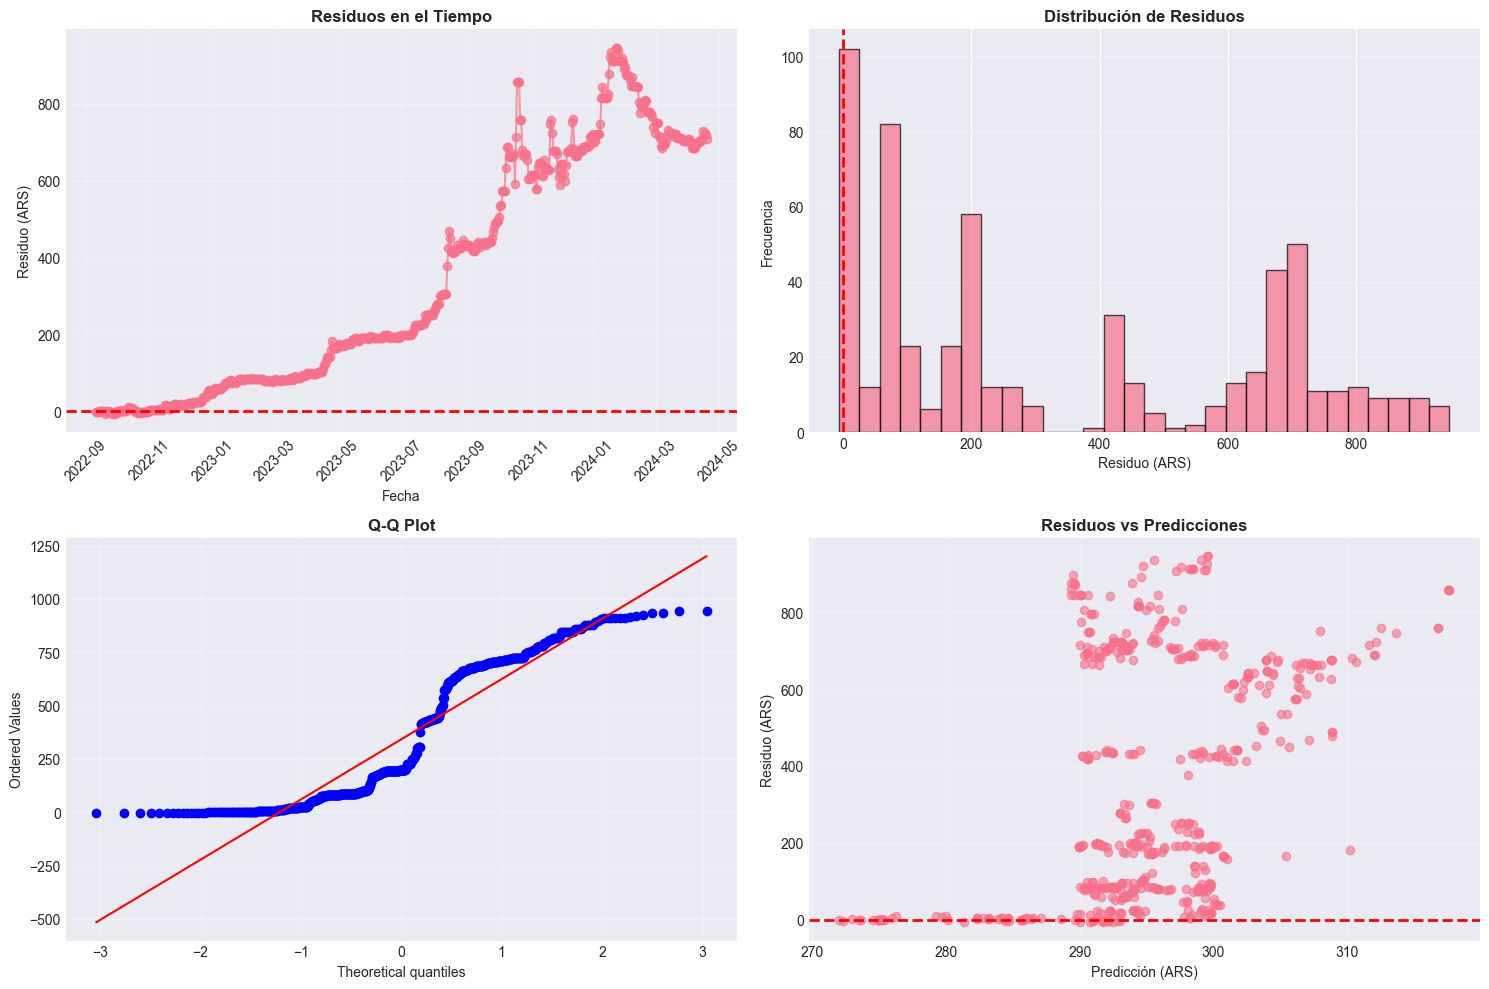

✓ Análisis de residuos guardado en ../src/models/models/residuals_analysis.png


In [27]:
# Calcular residuos del mejor modelo
if 'Stacking' in best_model_name:
    residuals = y_stack_val - best_predictions
    dates_residuals = dates_adj[split_idx:]
else:
    residuals = y_true_adj - best_predictions
    dates_residuals = dates_adj

# Visualización de residuos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuos en el tiempo
axes[0, 0].plot(dates_residuals, residuals, marker='o', linestyle='-', alpha=0.7)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_title('Residuos en el Tiempo', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Residuo (ARS)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Histograma de residuos
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_title('Distribución de Residuos', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residuo (ARS)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuos vs Predicciones
axes[1, 1].scatter(best_predictions, residuals, alpha=0.6)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_title('Residuos vs Predicciones', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicción (ARS)')
axes[1, 1].set_ylabel('Residuo (ARS)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/models/models/residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Análisis de residuos guardado en ../src/models/models/residuals_analysis.png')

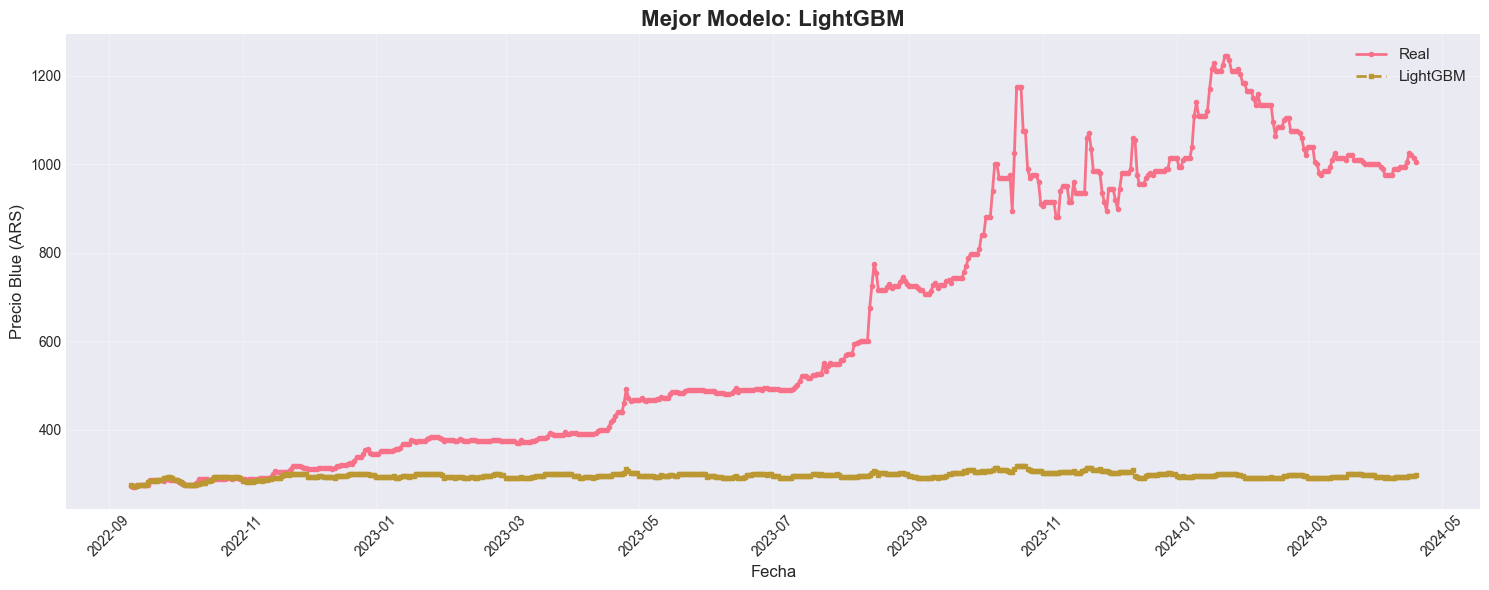

✓ Gráfico guardado en ../src/models/models/best_model_predictions.png


In [28]:
# Visualizar predicciones del mejor modelo
plt.figure(figsize=(15, 6))

if 'Stacking' in best_model_name:
    # Para stacking, usar solo la parte de validación
    plt.plot(dates_adj[split_idx:], y_stack_val, label='Real', linewidth=2, marker='o', markersize=3)
    plt.plot(dates_adj[split_idx:], best_predictions, label=f'{best_model_name}', 
             linewidth=2, linestyle='--', marker='s', markersize=3)
else:
    plt.plot(dates_adj, y_true_adj, label='Real', linewidth=2, marker='o', markersize=3)
    plt.plot(dates_adj, best_predictions, label=f'{best_model_name}', 
             linewidth=2, linestyle='--', marker='s', markersize=3)

plt.title(f'Mejor Modelo: {best_model_name}', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio Blue (ARS)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../src/models/models/best_model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Gráfico guardado en ../src/models/models/best_model_predictions.png')

## 7. Guardar Modelo Final

In [29]:
# Guardar configuración del mejor modelo
final_model_config = {
    'best_model': best_model_name,
    'metrics': {
        'mae': float(comparison_df.iloc[0]['MAE']),
        'rmse': float(comparison_df.iloc[0]['RMSE']),
        'mape': float(comparison_df.iloc[0]['MAPE'])
    },
    'ensemble_type': None,
    'weights': None,
    'meta_model': None
}

# Guardar información específica según el tipo de modelo
if 'Simple' in best_model_name:
    final_model_config['ensemble_type'] = 'simple_average'
    if has_nbeats:
        final_model_config['weights'] = [1/3, 1/3, 1/3]
    else:
        final_model_config['weights'] = [0.5, 0.5]
        
elif 'Ponderado' in best_model_name:
    final_model_config['ensemble_type'] = 'weighted_average'
    if has_nbeats:
        final_model_config['weights'] = [float(w_arima), float(w_lgb), float(w_nbeats)]
    else:
        final_model_config['weights'] = [float(w_arima), float(w_lgb)]
        
elif 'Stacking' in best_model_name:
    final_model_config['ensemble_type'] = 'stacking'
    meta_name = best_model_name.split('(')[1].split(')')[0]
    final_model_config['meta_model'] = meta_name
    
    # Guardar el meta-modelo
    with open('../src/models/models/meta_model.pkl', 'wb') as f:
        pickle.dump(best_model_obj, f)
    print('✓ Meta-modelo guardado')

# Guardar configuración
with open('../src/models/models/final_model_config.json', 'w') as f:
    json.dump(final_model_config, f, indent=4)

print('\n✓ Configuración del modelo final guardada')
print(f'  Tipo: {final_model_config["ensemble_type"]}')
if final_model_config['weights']:
    print(f'  Pesos: {final_model_config["weights"]}')
if final_model_config['meta_model']:
    print(f'  Meta-modelo: {final_model_config["meta_model"]}')


✓ Configuración del modelo final guardada
  Tipo: None


In [30]:
# Guardar comparación completa
comparison_df.to_csv('../src/models/models/ensemble_comparison.csv', index=False)
print('\n✓ Comparación guardada en ../src/models/models/ensemble_comparison.csv')


✓ Comparación guardada en ../src/models/models/ensemble_comparison.csv


## 8. Análisis de Residuos

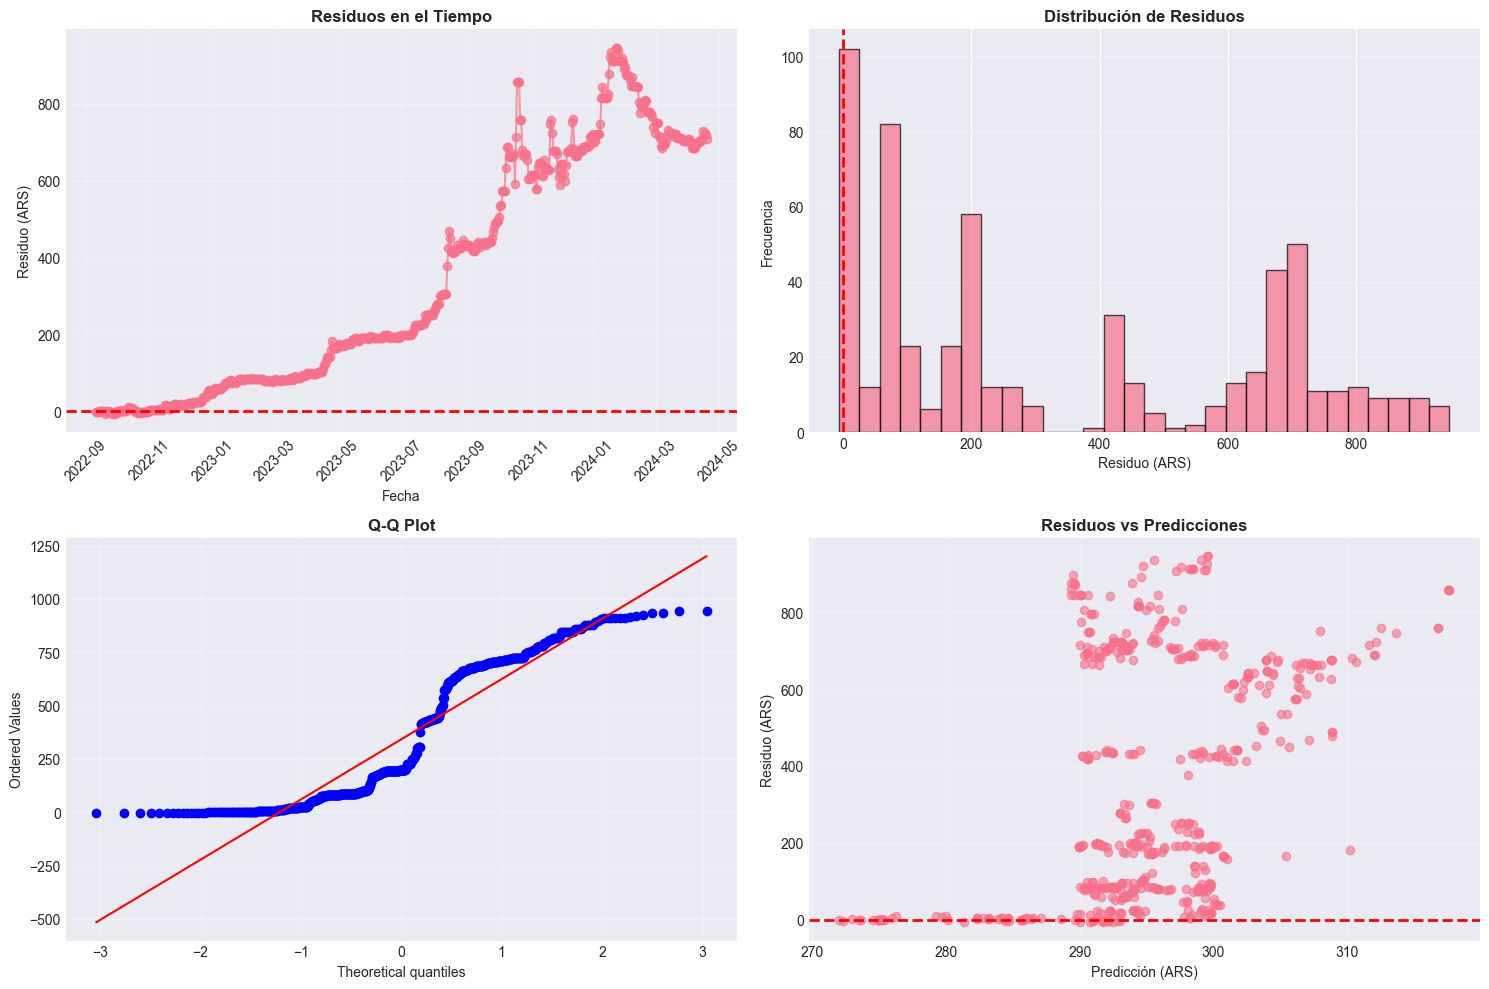

✓ Análisis de residuos guardado en ../src/models/models/residuals_analysis.png


In [31]:
# Calcular residuos del mejor modelo
if 'Stacking' in best_model_name:
    residuals = y_stack_val - best_predictions
    dates_residuals = dates_adj[split_idx:]
else:
    residuals = y_true_adj - best_predictions
    dates_residuals = dates_adj

# Visualización de residuos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Residuos en el tiempo
axes[0, 0].plot(dates_residuals, residuals, marker='o', linestyle='-', alpha=0.7)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_title('Residuos en el Tiempo', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Residuo (ARS)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Histograma de residuos
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_title('Distribución de Residuos', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residuo (ARS)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuos vs Predicciones
axes[1, 1].scatter(best_predictions, residuals, alpha=0.6)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_title('Residuos vs Predicciones', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicción (ARS)')
axes[1, 1].set_ylabel('Residuo (ARS)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/models/models/residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Análisis de residuos guardado en ../src/models/models/residuals_analysis.png')

In [32]:
# Estadísticas de residuos
print('\nEstadísticas de Residuos:')
print(f'  Media: {np.mean(residuals):.2f}')
print(f'  Desviación estándar: {np.std(residuals):.2f}')
print(f'  Mínimo: {np.min(residuals):.2f}')
print(f'  Máximo: {np.max(residuals):.2f}')
print(f'  Mediana: {np.median(residuals):.2f}')

# Test de normalidad
_, p_value = stats.shapiro(residuals)
print(f'\nTest de Shapiro-Wilk (normalidad):')
print(f'  p-value: {p_value:.4f}')
if p_value > 0.05:
    print('  ✓ Los residuos siguen una distribución normal')
else:
    print('  ⚠ Los residuos NO siguen una distribución normal')


Estadísticas de Residuos:
  Media: 341.74
  Desviación estándar: 301.47
  Mínimo: -6.33
  Máximo: 945.50
  Mediana: 198.02

Test de Shapiro-Wilk (normalidad):
  p-value: 0.0000
  ⚠ Los residuos NO siguen una distribución normal


## 9. Resumen Final

In [33]:
print('\n' + '='*70)
print('RESUMEN FINAL - ENSEMBLE MODELING')
print('='*70)
print(f'\n🏆 Mejor Modelo: {best_model_name}')
print(f'\nMétricas en Validation:')
print(f'  MAE:  {comparison_df.iloc[0]["MAE"]:.2f} ARS')
print(f'  RMSE: {comparison_df.iloc[0]["RMSE"]:.2f} ARS')
print(f'  MAPE: {comparison_df.iloc[0]["MAPE"]:.2f}%')

print(f'\nMejora respecto al mejor modelo individual:')
best_individual_mae = min(mae_arima, mae_lgb)
improvement = ((best_individual_mae - comparison_df.iloc[0]['MAE']) / best_individual_mae) * 100
print(f'  {improvement:.2f}% de reducción en MAE')

print(f'\nArchivos guardados en ../src/models/models/:')
print('  ✓ final_model_config.json')
print('  ✓ ensemble_comparison.csv')
print('  ✓ ensemble_comparison.png')
print('  ✓ best_model_predictions.png')
print('  ✓ residuals_analysis.png')
if 'Stacking' in best_model_name:
    print('  ✓ meta_model.pkl')
print('='*70)


RESUMEN FINAL - ENSEMBLE MODELING

🏆 Mejor Modelo: LightGBM

Métricas en Validation:
  MAE:  341.99 ARS
  RMSE: 455.71 ARS
  MAPE: 41.88%

Mejora respecto al mejor modelo individual:
  0.00% de reducción en MAE

Archivos guardados en ../src/models/models/:
  ✓ final_model_config.json
  ✓ ensemble_comparison.csv
  ✓ ensemble_comparison.png
  ✓ best_model_predictions.png
  ✓ residuals_analysis.png
